# Feature analysis — `volume_surge`

This notebook follows the project's feature-analysis **method** (the current cross-venue-gap template,
sibling to `trade_rate_surge`) on a new feature: **`volume_surge`** — a fast/slow ratio of a venue's mean
traded **volume** per trade. The text says what to do and why; the code does it.

We build features for a model that forecasts one exchange's mid-price about 100 ms ahead. Three
crypto exchanges appear throughout — **byb** (Bybit), **bin** (Binance), **okx** (OKX) — and
**byb is the target**: the one we predict. ("Mid-price" = the midpoint between the best buy and
best sell quote.) The next section recaps the model these features feed.

**The feature, in one line.** A venue's traded **volume** is the size (`qty`) that prints on *that venue*.
Smooth that size two ways — a **fast** EMA and a **slow** EMA, read as the self-normalising mean per trade
`E/W` — and take the ratio:

`volume_surge(ex; fast, slow) = (E/W)_fast(qty) / (E/W)_slow(qty)`

A *higher* ratio means that venue is trading *heavier than its own recent baseline* right now — a volume
**surge**; a *lower* ratio, a lull. Note the threshold is **not 1**: for heavy-tailed bursty volume the
fast/slow ratio is right-skewed (median ≪ mean), so the **typical** reading sits well below 1 — on this
block the per-venue medians are byb 0.29 / okx 0.35 / bin 0.31 — and "surge vs lull" is relative to that
**per-venue median**, not to 1. (§8 takes the log and robust-z-scores it, which re-centres on the median, so
the network sees a properly centred signal.) The hypothesis is that a surge **predicts intensity**: when a
venue starts trading in heavier size, more byb mid-moves are about to follow. Because it is a ratio of two
EMAs of the *same* quantity, the absolute size units cancel — so **no yardstick division is needed**.

**This is a per-exchange feature (like the template's dislocation gap).** Exactly as the template's gap
feature computes a value for *each* venue, and `trade_rate_surge` a surge for each venue, we compute a
volume surge for **each** venue — byb, okx **and** bin — each from that venue's OWN trades, and ask
whether it predicts **byb's** next move. The byb leg is the *target's own* trade size; the okx/bin legs
are **cross-venue** volume lead/lag.

**A feature's *analysis* is done when two checks pass:**
- **The parity check (§4)** — a production-style streaming build reproduces the feature on real data, so
  the code really computes what we think it does (**for every per-exchange leg**).
- **The hygiene gates (§5/§6)** — the signal is real and holds in any market, not just an echo of
  "the market is busy right now."

Everything after that decides *which part of the model* the feature feeds, and *at what time-scale* —
and the §10 checklist (streaming builder, tests, multi-block OOS) gates **shipping**: analysis-done is
not ship-done.

> **Control-circularity caveat (read this first — it is the crux of this feature).** The model's rate
> control `rate_momentum` is a fast/slow ratio of **`λ_ev`, byb's mid-MOVE rate**. `volume_surge` is a
> fast/slow ratio of byb's (and okx's, bin's) **traded VOLUME**. **These are NOT the same quantity.** A
> heavy print need not move the mid (it can fill inside the spread, or against deep resting liquidity,
> leaving the mid put), and the mid moves without a heavy print (a thin sweep or a quote revision). So even
> the **byb** volume leg is *not* a re-parameterisation of `rate_momentum` — byb's traded volume and its
> move rate decouple, and the volume may carry intensity information the move-rate control does not. The
> okx/bin legs add a *second* layer of newness — another venue's volume tempo. So the honest question,
> **per leg (byb included)**, is the **marginal value over the rate/vol controls** (§6/§9): does volume
> surge add over what the move-rate regime already says? This is why `volume_surge` is a **control**-kind
> feature (a volume regime descriptor) but **every** leg is judged on its **marginal** over the move-rate
> controls, not standalone.

## The model these features feed: two heads

A feature is only worth something if it helps the model predict, so it's worth knowing what the
model does. We forecast how byb's mid-price moves over the next ~100 ms, split into two simpler
questions — the two **heads**:

**Price head — which way and how far?** Over the next few price-moves, what is the *signed* move
(direction *and* size, together), in units of byb's recent **volatility** — the **volatility
yardstick** `σ_ev` (the exp-weighted RMS of byb's *actual* mid-moves)? Target: `price change ÷ σ_ev`.

**Rate head — how many moves?** Busy markets pack many price-moves into the window, quiet ones few.
This head predicts the *count* of moves over the next 100 ms, measured against the recent pace — the
**rate yardstick** `λ_ev` — so its target is `count ÷ λ_ev`.

**What's a yardstick?** A causal, trailing estimate of byb's *volatility* (`σ_ev`) and move *rate*
(`λ_ev`), from past data only. Both are EMAs **decayed on the trade clock** (`α = 2/(span+1)`) but
**updated between trades**. `λ_ev` is byb's **mid-moves per second** = the exp-weighted byb move-count
`W` ÷ the exp-weighted seconds-per-trade `dt`. **Note carefully:** `λ_ev` counts byb **mid-MOVES**;
`volume_surge` measures **traded VOLUME**. They share the same shared clock but a different quantity —
and that gap (volume ≠ moves) is exactly where this feature's potential marginal value lives.

**Why split into two heads?** A move over a window is *how many* little moves times *how big* each one
is. Pulling "how many" (rate) apart from "how big" (price) lets each head learn a steadier thing. This
"how many × how big" split is the classic **subordination** model of asset prices (Clark, 1973; Ané &
Geman, 2000): returns over fixed clock-time look messy but become well-behaved once you condition on the
*number* of events. Volume is the canonical **clock** in that model — trade volume subordinates price —
so `volume_surge` is squarely a **how-many** feature: it speaks to the rate head.

Two diagnostics recur below: does a feature's *signed* value predict the move (price head), and does its
*magnitude* predict how many moves come (rate head)? The model is fed the **signed** feature for *both*
heads; the rate head learns the magnitude itself. For `volume_surge` we expect the rate head to be where
it lives, if anywhere.

## Guard rails — do this, not that

Hard rules, learned the hard way. Follow them unless you have a specific, written reason not to.

**Don't**
- **Don't assume a fixed leader.** No exchange always leads — leadership moves around. Build the
  feature the same way for **every** venue and keep them all. (Here that is literal: byb, okx and bin
  each get their own volume surge leg; the okx/bin legs are exactly the "does another venue lead byb?"
  test.)
- **Don't pick "the best exchange"** by average score — that throws away the moments another venue
  leads. Keep all; let the model weight them.
- **Don't pool exchanges by default.** Check per-exchange vs single vs pooled across time-scales (§9).
- **Don't trust a correlation** until it survives the regime controls (rate and vol). For this feature
  the control is `rate_momentum` (byb's *move*-rate momentum) — and the open question is whether
  volume surge adds **over** it, since traded volume ≠ move rate.
- **Don't ship a feature without the §4 parity check** — a production-style build matching the
  vectorized version on real data, for **every** per-exchange leg.
- **Don't hand-roll a streaming EMA, and don't use `EventEMA` — use only `KernelMeanEMA` or `LiveFrontEMA`.**
  Every *online* average — the §4 production/streaming parity build, and any event-by-event EMA state anywhere
  in the notebook — MUST be exactly one of **two** `boba.ema` classes: **`KernelMeanEMA`** (the self-normalising
  `E / W` read — for a **flow**) or **`LiveFrontEMA`** (the live-front read — for a **level**). Both expose
  **separate `tick()` (decay) and `add()` (inject)** calls — that separation is the whole point: decay rides the
  shared trade clock (once per trade-timestamp) while injection rides each relevant-event timestamp, and the two
  must fire **independently** (see the inject-≠-decay rule below). **Never use `EventEMA`:** its single `step()`
  **couples decay and injection** into one call, so it *cannot* decay on the trade clock while injecting on a
  different event stream — that directly violates the inject-once / decay-once-independently rule. And **never**
  hand-roll a scalar EMA (no private `_ScalarEMA`, no `(1−α)·s + α·x` per-event loop) or reach for
  `scipy.signal.lfilter` in the streaming build. Every quantity here is either a **flow** (→ `KernelMeanEMA`) or
  a **level** (→ `LiveFrontEMA`); if you think you need anything else, you've mis-modelled it (a slope/covariance
  is a ratio of flow EMAs — several `KernelMeanEMA`s, not a bespoke class). §4 exists to validate the **actual
  production code** (`boba.ema` online vs §3's vectorized path), not a throwaway re-implementation that could
  carry the same blind spot. (The §3 *vectorized* analysis may still use `lfilter` — the offline array path, not
  online EMA state.)
- **Don't peek ahead.** Every value uses only data at-or-before its own timestamp.
- **Don't normalize reflexively.** `volume_surge` is a **ratio of two EMAs of the same quantity** —
  already dimensionless and comparable across calm/busy markets — so it needs **no** yardstick division.
- **Don't over-transform for the network.** Pick the lightest reshaping that works (§8).

**Do**
- **Do start with a falsifiable hypothesis** — a surge in a venue's traded volume precedes more byb
  mid-moves. Disproof: no link to the forward move-count at any time-scale, or a link that vanishes once
  we control for `rate_momentum`/`rate_level` (then it *was* just the move-rate regime); for okx/bin, no
  cross-venue marginal over byb's own.
- **Do make every average a trade-tick EMA.** *Every* smoother — every venue's volume legs, `σ_ev`,
  `λ_ev` — is an exponential moving average **decayed once per trade-timestamp** (`α = 2/(span+1)`) yet
  **updated on every relevant event between trades**, never a wall-clock or boxcar window. O(1) state,
  bit-identical online vs offline.
- **Do read a sparse flow as `E / W` on the shared clock.** Each venue's `qty` is present on only *some*
  timestamps; read it as the self-normalising `E/W` mean — `E` the exp-weighted summed qty, `W` the
  exp-weighted byb-trade count, both decayed every trade on the **one** shared clock, injected only on
  **that venue's** trade. The `E/W` form makes the many non-venue ticks cancel instead of counting as
  zeros, and divides out the warm-up bias — genuine per-venue mean qty from one clock (tight at large
  spans, fraying at small spans where cross-venue lead/lag lives — exactly the regime §9 probes).
- **Do treat all records sharing a timestamp as ONE event.** The decay clock advances **once** per
  trade-timestamp; a venue's N simultaneous prints are one event — we **sum** their `qty` into a single
  injection, not N. (78% of byb prints share a timestamp here, so this matters: a single order sweeping
  levels is one trade *event* carrying many fills — summed, not a sequence.)
- **Do test against both heads — but feed both the *signed* feature.** The magnitude→intensity
  (rate-head) check is the one that matters; the price-head check is a diagnostic we expect to be weak.
- **Do score out-of-sample** with a purged, embargoed walk-forward (strictly past→future).
- **Do treat a feature as a family across time-scales** and sweep the WHOLE fast×slow grid, per venue.
- **Do prove regime-invariance with Gate A — never assume it.** A surge ratio *should* be scale-stable
  and not track the regime level, but **measure** it (§6) — a level in disguise fails Gate A. And because
  `volume_surge` is itself a (volume) regime descriptor, `FEATURE_KIND = "control"`; but the control is
  the *move* rate while the feature is the *volume*, and volume ≠ move rate, so **every** leg is judged on
  its **marginal** over the move-rate controls — the honest "does volume add over move tempo?" test.

## 1. What the feature is, and why it might work

| | |
|---|---|
| **what** | a venue's mean traded **volume** per trade (`E/W` of `qty`), smoothed fast vs slow, as a **ratio** — one per venue (byb, okx, bin) |
| **feeds** | the **rate head** (intensity: how many byb moves next) is the natural home; price-head is a diagnostic |
| **predicts** | byb's 100 ms move-count (and, weakly if at all, direction) |

**The idea.** Take a venue's traded size `qty`. Read its exp-weighted mean per trade as `E/W` (sum of
`qty` ÷ count of byb trades). Smooth that mean two ways (a *fast* span, a *slow* span) and divide:
`surge = (E/W)_fast(qty) / (E/W)_slow(qty)`. A *higher* ratio = that venue is trading heavier than its
recent baseline; a *lower* ratio = lighter. The baseline that separates surge from lull is the **per-venue
median** (≈ 0.3 here), **not 1** — a fast/slow ratio of heavy-tailed bursty qty is right-skewed with a
median well below the mean. **Do this for byb, okx and bin** — the byb leg is the target's own size, the
okx/bin legs are other venues' size.

**Why it should work.** Volume clusters. When information arrives or inventory is worked, a venue's print
*size* swells and the elevated regime persists for tens to hundreds of milliseconds, so a fresh **surge**
forecasts a **burst** of upcoming byb mid-moves. For the **cross-venue** legs there is an extra mechanism:
if okx (or bin) starts trading in size first, that volume can **lead** byb's activity by a beat — the
classic no-fixed-leader lead/lag the template warns about. This is an *intensity* statement: it speaks to
*how many* moves, not *which way* — so the **rate head**.

**Why this might add over the move-rate control (the crux).** Here the byb leg measures **traded volume**,
and **volume ≠ mid-move rate**: a flurry of heavy fills inside the spread swells the volume without moving
the mid; a lone quote revision moves the mid with no trade at all. So byb's volume surge can decouple from
`rate_momentum` and may carry intensity the move-rate control misses (e.g. a build-up of trading *size*
that precedes the moves rather than coinciding with them). Whether it actually does is an empirical
question — §6 answers it as the marginal over the controls. The okx/bin legs carry that newness plus a
cross-venue dimension.

**What would disprove it.** No link to the forward byb move-count at any (fast, slow) for any venue; the
byb leg's link fully explained by `rate_momentum`/`rate_level` (then volume carried nothing the
move-rate regime didn't); or the okx/bin legs adding ≈0 over byb's controls (cross-venue volume tempo
carries nothing byb's own doesn't).

> **No fixed leader.** Built the same way for every venue, all kept. The okx/bin legs are precisely the
> "another venue might lead" test; the trade clock pools all three venues' trades (the shared "tick").

## Choosing the EMA — the part that's easy to get silently wrong

Every smoother here is an EMA on the **trade clock**: its **decay** steps once per *trade-timestamp*
(`α = 2/(span+1)`), but its **value updates on every relevant event in between**, so a read between
trades is never stale. For each venue's `volume_surge` the moving parts are:

- **The `E/W` mean qty per trade** — a **sparse flow** (venue `ex` prints qty on only *some* shared
  timestamps). The right object is a **`KernelMeanEMA`**: `add(Σ qty of this timestamp's prints)` on each
  `ex` trade-timestamp (weight 1), `tick()` (decay) on every shared trade-timestamp. `E` is the
  exp-weighted summed qty; `W` is the exp-weighted count of `ex` trade-timestamps; the read `E/W` is the
  **exp-weighted mean qty per `ex` trade**, with the non-venue ticks cancelling and the warm-up bias
  divided out. `volume_surge` is the ratio of two such reads at a fast and a slow span.
- **`σ_ev` / `λ_ev`** (the yardsticks) are the same `E/W` pattern over byb's *mid-move* stream, span
  `YARDSTICK_N`, used only to build the §5 controls and the rate-head *target* — never inside the feature.

The trap the template warns about (push a value where there is no event) applies here too: the qty EMA
must inject **only** on a real `ex` trade-timestamp, and **once** per timestamp (simultaneous prints are
one event — sum their qty, one injection, not N). Pushing a `0` on a non-`ex` trade would silently turn
"mean qty per `ex` trade" into "mean qty per *any* trade" (diluted by the other venues' trade rate). Because
the qty self-ratio cancels both the common decay and the warm-up, the surge divides by **no** yardstick of
either head's target — that is why `STRAT_VAR = None` in §5. The §4 parity check re-derives all of this from
raw events, per venue, and confirms it bit-exact.

> **One degeneracy to flag.** `span = 1` sets `α = 1`, which **fully decays an `E/W` flow to 0 each tick**
> (`E` reads 0 right after the decay), so span=1 means "no memory at all", **not** "no smoothing" — the
> smallest useful span for a flow is **2**. (A *level*'s `LiveFrontEMA` reads the fresh value before the
> decay, so span=1 is fine there — but `volume_surge` is a flow, so the family starts at 2.)

## 2. The exact definition

A definition has to get three things right.

**Causal** — only data up to the moment it's computed; no peeking.

**Measured on the trade clock** — markets alternate busy and quiet, so we count progress in *trades*
(one tick per trade-timestamp on any exchange — simultaneous prints are one tick) rather than
clock-seconds. Book updates between trades do not advance the clock; only a trade decays the EMAs once.

**Comparable across calm and wild markets** — and here it already is: `volume_surge` is a **ratio of
two EMAs of the same quantity**, so the absolute size cancels (a market with intrinsically large prints
and one with small prints have the **same** surge distribution — the size units drop out). That common
distribution is **not centred at 1**: a fast/slow ratio of heavy-tailed bursty qty is right-skewed with a
median well below the mean, so the typical reading sits ≈ 0.3 (log-surge centred ≈ −1.2) on this block, and
the surge/lull baseline is that **per-venue median**, not 1. What cancels is the *scale*, not the location —
which is why §8 re-centres with a log + robust-z. **No `σ_ev` / `λ_ev` division** is applied to the
feature. The yardsticks still appear — to build the §5 controls and the rate-head *target* — but not
inside the feature.

Put it together, **for each venue `ex`**:

**2a — The shape** (the whole idea, in one line):

`volume_surge(ex) = (E/W)_fast(qty) / (E/W)_slow(qty)`,  where each `(E/W)_N(qty)` = ex's exp-weighted mean qty per trade at span `N`.

A fresh swelling on venue `ex` shows up as its fast mean-qty pulling above its slow one (ratio > 1).

**2b — The EMAs we use, and how they update:**

- **Both legs** — a **`KernelMeanEMA`** read as `E/W` over the `ex`-trade stream: decay once per
  trade-timestamp on the shared clock (`α=2/(N+1)`), `add(Σ qty)` on each real `ex` trade-timestamp
  (simultaneous prints summed → one injection), read `E/W` (mean qty per `ex` trade) at the anchor.
  `n_fast` < `n_slow`.
- **`σ_ev`, `λ_ev`** (yardsticks, span `YARDSTICK_N`) — used only for the controls and the rate-head
  target: `σ_ev = √(E/W)` over **byb mid-moves**; `λ_ev = W_byb / dt` at `YARDSTICK_N` (byb's mid-MOVE
  rate — distinct from this feature's traded volume).

§3 builds exactly this; §4 re-derives it from raw events, per venue, and confirms it bit-exact. The cell
below loads the data, builds the shared trade clock, computes each venue's per-timestamp summed-qty
stream and byb's mid-move stream, and computes both yardsticks (from byb) on that clock, span `YARDSTICK_N`.

In [1]:
import numpy as np, polars as pl
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from scipy.stats import spearmanr
from boba.io import list_blocks, load_block

COIN        = "eth_usdt_p"
TARGET      = "byb_eth_usdt_p"                    # the exchange we PREDICT; byb mid also feeds σ_ev/λ_ev & the targets
EXCHANGES   = ["byb", "okx", "bin"]              # EVERY venue gets its own volume-surge leg (byb = own size; okx/bin = cross-venue)
MID_STREAM  = {"bin": "front_levels", "byb": "merged_levels", "okx": "merged_levels"}  # byb mid (for yardsticks/target) = merged; bin = front_levels (merged blocked for bin perp)
FAST        = [2, 10, 50, 200]                   # fast volume-EMA spans — the WHOLE family swept. NB: span=1 (α=1) is DEGENERATE
                                                 # for an E/W flow (E decays to 0 each tick), so the smallest useful flow span is 2.
SLOW        = [100, 500, 2000, 5000]             # slow volume-EMA spans (each must exceed the fast one)
HORIZON_NS  = 100 * 1_000_000                    # how far ahead we predict (100 ms, in nanoseconds)
YARDSTICK_N = 10000                              # the ONE span for BOTH yardsticks (σ_ev, λ_ev): trade-tick EMA α=2/(N+1)
block       = list_blocks(TARGET, "front_levels")[0]   # one ~24h slice of recorded data

# byb mid stream (for the yardsticks + targets only; this feature itself needs NO mid)
def load_mid(ex):
    df = (load_block(block, f"{ex}_{COIN}", MID_STREAM[ex]).select("rx_time", "bid_prc", "ask_prc").drop_nulls())
    return df["rx_time"].cast(pl.Int64).to_numpy(), (df["bid_prc"].to_numpy() + df["ask_prc"].to_numpy()) / 2
byb_rx0, byb_mid0 = load_mid("byb")

# load each venue's TRADES: rx_time + qty, prc/qty>0 filtered. The qty is the raw atom of this feature.
trade_rx_all = {}; trade_qty_all = {}
trade_ts = []
for ex in EXCHANGES:
    td = (load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "prc", "qty")
          .filter((pl.col("prc") > 0) & (pl.col("qty") > 0)))         # drop bad prc=qty=0 prints
    rx = td["rx_time"].cast(pl.Int64).to_numpy(); q = td["qty"].to_numpy()
    trade_rx_all[ex] = rx; trade_qty_all[ex] = q
    trade_ts.append(rx)
trade_prints = np.concatenate(trade_ts)
merged_ts = np.unique(trade_prints)                               # the shared trade clock: one tick per trade-TIMESTAMP (any venue)
n_ticks = len(merged_ts)
byb_dt = np.zeros(n_ticks); byb_dt[1:] = np.diff(merged_ts) / 1e9 # seconds between consecutive trades (shared clock)
print(f"trade clock: {n_ticks:,} ticks (timestamps) from {len(trade_prints):,} trade prints")

# per-venue: total qty per trade-TIMESTAMP (simultaneous prints SUMMED into ONE event — never a sequence)
QTY = {}                                                          # ex -> (unique trade timestamps, summed qty at each)
for ex in EXCHANGES:
    u, inv = np.unique(trade_rx_all[ex], return_inverse=True)
    QTY[ex] = (u, np.bincount(inv, weights=trade_qty_all[ex]))
print("summed simultaneous prints:  " + "  ".join(f"{ex}: {len(trade_rx_all[ex]):,}->{len(QTY[ex][0]):,} ts" for ex in EXCHANGES))

# --- byb mid-move stream backs σ_ev/λ_ev and the prediction targets ---
keep = np.concatenate([byb_rx0[1:] != byb_rx0[:-1], [True]])                     # collapse same-TIMESTAMP mids to ONE update (final mid)
byb_rx, byb_mid = byb_rx0[keep], byb_mid0[keep]
byb_lm = np.log(byb_mid)
byb_blr = np.empty_like(byb_lm); byb_blr[0] = 0.0; byb_blr[1:] = np.diff(byb_lm)  # byb log-return per timestamp
mv = byb_blr != 0.0                                                              # a REAL byb mid-MOVE
mv_rx, mv_r2 = byb_rx[mv], byb_blr[mv] ** 2
cum_mv = np.concatenate([[0.0], np.cumsum(mv.astype(float))])                    # running byb move count (rate-head target)

def _ewma(x, span):                                                # per-trade EMA (seconds/trade leg; shared clock)
    a = 2.0 / (span + 1.0); return lfilter([a], [1.0, -(1.0 - a)], x)
def _flow_at(ev_rx, val, anchors, span):    # live E/W-style EWMA of `val` over a sparse event stream (ev_rx), decayed once per trade-timestamp, read AT each anchor
    a = 2.0 / (span + 1.0)
    k = np.searchsorted(merged_ts, ev_rx, "left")                               # trades strictly before each event (a same-rx trade decays it)
    ep = np.bincount(k, weights=val, minlength=n_ticks + 1)                     # per-trade-epoch sums
    x = np.zeros(n_ticks + 1); x[1:] = a * (1.0 - a) * ep[:-1]
    com = lfilter([1.0], [1.0, -(1.0 - a)], x)                                  # committed E just after each trade
    ta = np.searchsorted(merged_ts, anchors, "right") - 1                       # last trade <= anchor
    cs = np.concatenate([[0.0], np.cumsum(val)])                               # prefix sums over the event stream (the partial epoch)
    partial = cs[np.searchsorted(ev_rx, anchors, "right")] - cs[np.searchsorted(ev_rx, merged_ts[ta], "right")]
    return com[ta + 1] + a * partial
def vol_per_trade(ex, anchors, span):       # venue ex's E/W mean traded volume per trade at a span (the surge leg, live at anchor)
    u, q = QTY[ex]
    e = _flow_at(u, q, anchors, span)                            # E: exp-weighted summed qty
    w = _flow_at(u, np.ones(u.size), anchors, span)             # W: exp-weighted ex trade-timestamp count
    return e / np.maximum(w, 1e-300)
def yardsticks(anchors, span):                                     # σ_ev, λ_ev from BYB MID-MOVES — defined AT the anchor
    e_sq = _flow_at(mv_rx, mv_r2, anchors, span)                  # E: exp-weighted squared byb moves
    e_mv = _flow_at(mv_rx, np.ones(mv_r2.size), anchors, span)    # W: exp-weighted byb-move count
    e_dt = _ewma(byb_dt, span)[np.searchsorted(merged_ts, anchors, "right") - 1]   # seconds/trade
    sig = np.sqrt(e_sq / np.maximum(e_mv, 1e-12))                 # σ_ev: RMS byb mid-move (E/W — non-moves cancel)
    lam = e_mv / np.maximum(e_dt, 1e-12)                          # λ_ev: byb mid-MOVES per second (NOT the traded volume)
    return sig, lam
print(f"yardsticks (from byb mid-moves): decay span {YARDSTICK_N} trades; λ_ev = byb MOVE rate (≠ this feature's traded VOLUME)")

trade clock: 1,682,255 ticks (timestamps) from 6,198,188 trade prints
summed simultaneous prints:  byb: 1,618,754->351,008 ts  okx: 889,567->585,948 ts  bin: 3,689,867->745,299 ts
yardsticks (from byb mid-moves): decay span 10000 trades; λ_ev = byb MOVE rate (≠ this feature's traded VOLUME)


## 3. Build it (twice)

Build the feature two ways: this fast array version for analysis, and — in production — a streaming
version that does constant work per trade (no growing buffers). They have to agree, which §4 checks.

We lay an evaluation grid every 50 ms (half the 100 ms horizon — plenty of samples; adjacent 100 ms
outcome windows still overlap ~50%, so neighbouring samples are correlated, which is exactly why §5's
walk-forward gate uses an embargo), read byb's actual move and move-count over the next 100 ms (the
things we're predicting), and compute the feature **per venue** at each grid point.

**The `E/W` build, vectorised.** For each venue and span: form `E` (EWMA of the per-timestamp summed
qty) and `W` (EWMA of the per-timestamp count) over the venue's sparse trade stream, decayed on the
**shared** clock, read at each anchor as the committed-per-trade EMA plus the partial epoch of that
venue's trades since the last shared trade. `volume_surge = (E/W)_fast / (E/W)_slow`. Because both legs
read the *same* fresh partial epoch, the ratio reacts the instant a fresh print lands.

In [2]:
# evaluation grid (causal) + forward targets
WARMUP = 5 * max(YARDSTICK_N, max(SLOW))   # = 50000: enough trades for the slowest EMA/yardstick to converge
anchor_ts      = np.arange(merged_ts[WARMUP], merged_ts[-1] - HORIZON_NS, 50 * 1_000_000)   # 50 ms grid, past warmup
tick_at_anchor = np.searchsorted(merged_ts, anchor_ts, "right") - 1                         # last trade-clock tick <= anchor
sigma_at_anchor, lam_at_anchor = yardsticks(anchor_ts, YARDSTICK_N)
print(f"σ_ev median {np.nanmedian(sigma_at_anchor):.2e},  λ_ev median {np.nanmedian(lam_at_anchor):.2f} moves/s")

# price-head target (a diagnostic for this volume feature): byb's 100 ms return ÷ σ_ev
mid_now    = byb_mid[np.searchsorted(byb_rx, anchor_ts, "right") - 1]
mid_fwd    = byb_mid[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right") - 1]
fwd_return = np.log(mid_fwd / mid_now)
target     = fwd_return / sigma_at_anchor                          # price-head target (σ-units)

def volume_surge(ex, n_fast, n_slow):       # THE FEATURE, per venue: ratio of venue ex's mean traded VOLUME per trade, fast span over slow span
    rf = vol_per_trade(ex, anchor_ts, n_fast)                     # fast E/W mean qty per trade
    rs = vol_per_trade(ex, anchor_ts, n_slow)                     # slow E/W mean qty (baseline size)
    return rf / np.maximum(rs, 1e-300)                            # higher = heavier than baseline, lower = lull (right-skewed: typical reading well below 1, baseline = per-venue median)
print(f"grid: {len(anchor_ts):,} anchors")
for ex in EXCHANGES:
    demo = volume_surge(ex, 10, 500)
    print(f"  volume_surge({ex},10,500): median {np.nanmedian(demo):.3f}  p10 {np.nanpercentile(demo,10):.3f}  p90 {np.nanpercentile(demo,90):.3f}")

σ_ev median 2.78e-05,  λ_ev median 1.18 moves/s


grid: 1,706,369 anchors


  volume_surge(byb,10,500): median 0.289  p10 0.041  p90 2.144


  volume_surge(okx,10,500): median 0.347  p10 0.059  p90 1.941


  volume_surge(bin,10,500): median 0.310  p10 0.062  p90 1.558


## 4. Check the code is right — a parity check (a production-style streaming build)

**Non-negotiable.** Reproduce the feature with a second, **independent** implementation and confirm the
two agree on real data, **bit-exact**, **for every per-exchange leg** — a **parity check**. The streaming
build is the **production** reference: an O(1) state machine you push **raw trade events** into and read
`value(ex)` from. State is two scalar `KernelMeanEMA`s per venue (fast + slow) — no buffers, no history,
independent of how long it runs.

This is deliberately a different code path from §3 (no `lfilter`, no `_flow_at`). It uses only plain
scalars plus `boba.ema.KernelMeanEMA` for the per-venue `E/W` qty mean:

- **The `E/W` mean qty, per venue per span** — a `KernelMeanEMA`: on a timestamp where venue `ex` traded,
  `add(Σ qty)` (one injection of the summed qty, weight 1); then on **every** trade-timestamp (any venue)
  `tick()` (decay). **read** `E/W` (mean qty per `ex` trade) at the anchor.
- **`volume_surge(ex) = (E/W)_fast / (E/W)_slow`**.

**Driver discipline (matches the trade clock):** apply every print at a timestamp (summing each venue's
qty), then `refresh()` once — inject each present venue's summed qty into its two EMAs, then advance the
clock (tick every venue's EMAs) **exactly once**, because a trade landed. (A timestamp here always has a
trade, since the only events fed are trades — trades *are* the clock — but we keep the trade-gated
discipline explicit so the shape matches the template.) We feed the **whole raw trade stream** — every
venue's trades — into **one** builder and read **every venue's** feature at each grid anchor.

In [3]:
from boba.ema import KernelMeanEMA   # self-normalising E/W flow mean, src/boba/ema.py

class LiveVolumeSurge:
    # Pure feature state machine for per-venue VOLUME surges. O(1), all scalar — no buffers, no history.
    # Per venue: a fast and a slow KernelMeanEMA over that venue's per-timestamp SUMMED qty.
    # on_trade only ACCUMULATES this timestamp's qty per venue; the driver calls refresh() ONCE per timestamp,
    # which injects each present venue's SUMMED qty (one event per timestamp, never per print) then advances the
    # shared clock once (decay every venue's EMAs). value() reads E/W_fast / E/W_slow per venue.
    def __init__(self, venues, n_fast, n_slow):
        self.venues = list(venues)
        self.fast = {v: KernelMeanEMA(n_fast) for v in self.venues}        # fast E/W mean qty per venue
        self.slow = {v: KernelMeanEMA(n_slow) for v in self.venues}        # slow E/W mean qty per venue
        self.pending = {}                                                  # venue -> summed qty at the current timestamp

    def on_trade(self, venue, qty):                                        # accumulate this timestamp's qty for the venue (sum simultaneous prints into ONE event)
        self.pending[venue] = self.pending.get(venue, 0.0) + qty

    def refresh(self):                                                     # ONE per TIMESTAMP: inject each present venue's summed qty, then decay everyone once
        for v, q in self.pending.items():                                  # inject only venues that traded this timestamp (sparse flow; non-traders stay non-observations)
            self.fast[v].add(q); self.slow[v].add(q)
        self.pending = {}
        for v in self.venues:                                              # a trade landed -> the shared clock advances once: decay every venue's EMAs
            self.fast[v].tick(); self.slow[v].tick()

    def value(self, v):                                                    # the feature for venue v: (E/W)_fast / (E/W)_slow
        f, s = self.fast[v].value(), self.slow[v].value()
        return f / s if (s == s and s != 0.0) else float("nan")

# --- gather the WHOLE raw trade stream (every venue's trades) over a slice ---
NF, NS, N_GRID = 10, 500, 40_000                   # validate ONE (fast,slow) pair, for ALL THREE venues, over the first ~N_GRID grid points
cutoff = int(anchor_ts[min(N_GRID, len(anchor_ts) - 1)])    # wall-clock time of the N_GRID-th grid anchor
cols = {k: [] for k in "rx eid qty".split()}       # eid = integer venue code
for eid, ex in enumerate(EXCHANGES):
    rx = trade_rx_all[ex]; q = trade_qty_all[ex]; m = rx <= cutoff; nkeep = int(m.sum())
    cols["rx"].append(rx[m]); cols["eid"].append(np.full(nkeep, eid, np.int8)); cols["qty"].append(q[m])
C = {k: np.concatenate(v) for k, v in cols.items()}
order = np.argsort(C["rx"], kind="stable")          # rx ascending; venue order within a tie is irrelevant (we sum)
rxL, eidL, qtyL = (C[k][order].tolist() for k in "rx eid qty".split())
print(f"streaming {len(rxL):,} raw trade events (all venues) over ~{N_GRID:,} grid points...")

# --- the CALLER drives it: apply each timestamp's trades, refresh() once, READ value() for EVERY venue at every grid anchor ---
feat = LiveVolumeSurge(EXCHANGES, NF, NS)
na = min(N_GRID, len(anchor_ts))
stream = {ex: np.full(na, np.nan) for ex in EXCHANGES}
n = len(rxL); i = 0; ai = 0
while i < n:
    rx = rxL[i]
    while ai < na and anchor_ts[ai] < rx:          # read every anchor whose state is settled (all events before rx applied)
        for ex in EXCHANGES: stream[ex][ai] = feat.value(ex)
        ai += 1
    while i < n and rxL[i] == rx:                  # apply EVERY print stamped at this nanosecond (sum into pending)
        feat.on_trade(EXCHANGES[eidL[i]], qtyL[i]); i += 1
    feat.refresh()                                 # apply the timestamp: inject each present venue's summed qty, advance the clock once
while ai < na:
    for ex in EXCHANGES: stream[ex][ai] = feat.value(ex)
    ai += 1

# --- one raw-trade stream -> three per-venue features: check EACH leg against its §3 vectorized feature, bit-exact ---
print(f"one raw-trade stream -> per-venue volume_surge legs, vs the vectorized build (Nf={NF}, Ns={NS}):")
worst = 0.0
for ex in EXCHANGES:
    ref = volume_surge(ex, NF, NS)[:na]
    both = np.isfinite(stream[ex]) & np.isfinite(ref)
    diff = np.abs(stream[ex][both] - ref[both]); mx = float(np.nanmax(diff)); worst = max(worst, mx)
    print(f"  {ex}:  max |diff| {mx:.2e}  on {int(both.sum()):,} grid points")
    assert mx < 1e-6, f"streaming build does not reproduce the {ex} feature (max|diff|={mx:.2e})"
print(f"parity: the raw-trade streaming build reproduces ALL THREE per-venue legs  OK  (worst |diff| {worst:.2e})")

streaming 585,061 raw trade events (all venues) over ~40,000 grid points...


one raw-trade stream -> per-venue volume_surge legs, vs the vectorized build (Nf=10, Ns=500):


  byb:  max |diff| 1.56e-13  on 40,000 grid points


  okx:  max |diff| 1.14e-13  on 40,000 grid points


  bin:  max |diff| 1.17e-13  on 40,000 grid points
parity: the raw-trade streaming build reproduces ALL THREE per-venue legs  OK  (worst |diff| 1.56e-13)


**Conclusion.** From one stream of raw trade events the streaming O(1) builder reproduces **every** venue's
vectorized feature to floating-point round-off — worst max |diff| printed above, far under the `1e-6` bar
(pure last-digit drift from the recursive EMAs). The two implementations share no code (the streaming build
uses plain scalar `KernelMeanEMA`s; §3 uses `lfilter`/`_flow_at`), so agreement means each leg computes what
we claim: that **venue's** exp-weighted mean traded qty per trade at two spans, ratioed. Crucially, the
streaming build independently **sums simultaneous prints into one event** and **decays the shared clock once
per timestamp** — matching it bit-exact confirms the vectorized `_flow_at` handles the 78%-simultaneous byb
prints correctly. The byb, okx and bin legs are all bit-exact, so the §3 per-venue build is trustworthy.
(The check runs at one (fast, slow) pair; the recursion is identical for every span, so this validates the
family.)

## 5. Is the signal real? — the hygiene gates (and the volume-vs-move-rate reckoning)

A correlation is an easy way to fool yourself. The gates are **two independent tests** (see the Gate A /
Gate B box in §6): **(A)** is the feature **regime-invariant** — a stable distribution that doesn't leak
the vol/rate state — and **(B)** does it **predict** something the market's current state doesn't already
tell us? The only **controls** for Gate B are the two **regime-invariant momenta**:
- **rate momentum** — from `λ_ev` (byb's mid-MOVE rate): is byb moving more or less often than its own
  recent pace?
- **vol momentum** — the same, for volatility.
The raw **levels** of vol and rate (`log σ_ev`, `log λ_ev`) are **not** controls — they aren't
regime-invariant, so they're never model features; we keep them only as the regime *coordinate* for Gate A.

"Predictive power" here is the **rank correlation** between feature and outcome (Spearman — robust to
outliers), scored **out-of-sample with a purged, expanding-window walk-forward**: each fold trains only
on the *past*, leaves an **embargo gap** sized to clear the 100 ms outcome windows with margin. Note the
embargo does **not** fully decorrelate the slow EMA/yardstick features: their memory is ≈ `YARDSTICK_N` /
(trades-per-sec) — longer than the ~100 s embargo — so re-check this if you slow the spans. We also report
the **per-fold** ICs and a **block-bootstrap 90% CI** so the headline respects the autocorrelation.

**The reckoning to watch — traded volume vs move rate.** `rate_momentum = log(λ_fast / λ_slow)` is a
fast/slow ratio of byb's **mid-MOVE** rate. `volume_surge` is a fast/slow ratio of byb's **traded VOLUME**.
**Volume ≠ move rate**, so even the byb leg is not a re-parameterised control — it can carry trading-size
intensity the move-rate control misses (a heavy fill inside the spread swells the volume without moving the
mid). The okx/bin legs add a further, cross-venue layer. So the honest question for **every** leg, byb
included, is the **marginal IC over these controls** (§6): does volume surge add over what the byb
move-rate regime already says? Because `volume_surge` *is* a volume regime descriptor we set
`FEATURE_KIND = "control"`, but **every** leg is scored on the **marginal** branch (`own=False`) — there is
no circular own-leg here, because the control is the *move* rate while the feature is the *traded volume*.

In [4]:
# --- the regime signals: the two INVARIANT momenta (the Gate B controls) + the two yardstick LEVELS
# (the regime COORDINATE for Gate A — used only to bucket/correlate against, NEVER as controls) ---
FAST_YARD = YARDSTICK_N // 10                        # a faster span (1/10 the yardstick) for the momentum controls
sig_fast, lam_fast = yardsticks(anchor_ts, FAST_YARD)
vol_level     = np.log(sigma_at_anchor)                                             # σ_ev — how volatile now
vol_momentum  = np.log(sig_fast / sigma_at_anchor)                                  # recent vol vs slower vol
rate_level    = np.log(lam_at_anchor)                                               # λ_ev = byb's mid-MOVE rate
rate_momentum = np.log(lam_fast / lam_at_anchor)                                    # recent MOVE rate vs slower MOVE rate (the control; NOT the traded volume)

# rate-head target = byb moves in the next 100 ms, divided by λ_ev (the rate yardstick) — the head this feature serves
fwd_count = (cum_mv[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right")]
             - cum_mv[np.searchsorted(byb_rx, anchor_ts, "right")])
rate_target = fwd_count / np.maximum(lam_at_anchor, 1e-9)   # count ÷ λ_ev ∝ "more/fewer moves than usual"

# The gate machinery (walk-forward IC, Gate A/B, the block-bootstrap CI) lives in the shared, TESTED
# library boba.research.gates — defined once and used by every feature notebook (see tests/test_gates*.py;
# externally validated against the literature and adversarially reviewed). We import the primitives here and
# bind the regime scaffolding below into thin wrappers, so the call sites read the same while the logic
# stays in one validated place.
from boba.research import gates as _gates
from boba.research.gates import ic, wf_folds, wf_ic, wf_ic_by_regime, stratified_ic

vol_regime = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], [33, 67]))   # 0 calm, 1 mid, 2 wild
# FEATURE_KIND drives GATE B below. "alpha" = a candidate signal that is NOT a regime descriptor
# (OFI, microprice, flow, price moves) -> judged on MARGINAL value over the controls. "control" = a
# regime descriptor (vol, rate, volume & their ratios/dynamics/SURGES) -> itself a valid feature.
# volume_surge IS a volume regime descriptor -> "control". BUT (the crux): the control is the MOVE rate
# while the feature is the traded VOLUME, and volume != move rate — so there is NO circular own-leg here.
# EVERY leg (byb included) is judged on its MARGINAL over the controls (own=False).
FEATURE_KIND = "control"                                               # volume_surge = a traded-volume surge -> a regime descriptor (but NOT circular with the MOVE-rate control)
base = [rate_momentum, vol_momentum]                                   # the ONLY controls: regime-INVARIANT momenta. Raw vol/rate LEVELS are never controls (not valid features).
levels = [rate_level, vol_level]                                       # the regime COORDINATE — used only for the §6 leak re-check, NEVER as a Gate B control.
# byb momenta proxy the GLOBAL regime — one instrument, cross-venue divergence is arbed away fast, so at this slow control scale all venues share one regime; foreign-venue momenta would just re-add it.
STRAT_VAR = None                                                       # mechanical-coupling guard (HIGH-2): the shared YARDSTICK to STRATIFY by. Set it to the
                                                                       # denominator of the *scored* target when the feature is a control RATIO dividing by it (count/λ_ev clone
                                                                       # -> lam_at_anchor; σ_ev thing on the σ_ev target -> sigma_at_anchor). volume_surge is (E/W)_fast(qty)/
                                                                       # (E/W)_slow(qty) — a self-ratio of the SAME quantity — so the qty units and any decay/warm-up factor CANCEL
                                                                       # in the ratio: the surge divides by NO yardstick of either target. No shared-denominator coupling -> None.
# Thin wrappers binding the scaffolding above to the shared gate library (call sites stay unchanged):
def signal_ic(leg_feats, *, own, tgt=None):                            # Gate B value (marginal-over-controls for a leg with own=False; standalone for own=True)
    return _gates.signal_ic(leg_feats, base, target if tgt is None else tgt,
                            feature_kind=FEATURE_KIND, own=own, strat_var=STRAT_VAR)
def signal_ic_by_regime(leg_feats, *, own, tgt=None):                  # the regime-stable companion (per calm/mid/wild bucket)
    return _gates.signal_ic_by_regime(leg_feats, base, target if tgt is None else tgt, vol_regime,
                                      feature_kind=FEATURE_KIND, own=own, strat_var=STRAT_VAR)
def gate_a(feat):                                                      # Gate A on one feature vs the vol/rate regime coordinates
    return _gates.gate_a(feat, vol_level, rate_level)
def wf_marginal_ci(legs, tgt, B=400, seed=0):                          # per-fold spread + block-bootstrap 90% CI for a headline marginal
    return _gates.marginal_ci(legs, base, tgt, B=B, seed=seed)

print("control-only predictive power (walk-forward), RATE head:")
print("  momenta        ", round(wf_ic(base, rate_target), 3))
print("  momenta+levels ", round(wf_ic(base + levels, rate_target), 3),
      " <- the MOVE-rate controls ALREADY predict the move-count; this is the bar each VOLUME-surge leg must beat")

control-only predictive power (walk-forward), RATE head:


  momenta         0.071


  momenta+levels  0.063  <- the MOVE-rate controls ALREADY predict the move-count; this is the bar each VOLUME-surge leg must beat


**Conclusion.** Unlike the price-head template (where the controls carried ~0 directional signal), here
the **move-rate controls predict the rate target on their own** — read the walk-forward rank-IC printed
above for the momenta (and momenta+levels): recent move-rate predicts upcoming move-rate, so that number is
the bar each leg must beat. **But the bar is set by the *move* rate, while the feature is the *traded
volume***, and the two are distinct (volume ≠ moves). That is the whole opportunity: a raw IC would partly
re-report volume's correlation with the move rate, so the only number that matters per leg is its **marginal
IC over these (move-rate) controls** (§6) — does trading-size intensity add over move tempo? The okx/bin
legs face the same bar but add a cross-venue dimension on top. Because the feature is the traded volume (not
the move rate), even the byb leg has a genuine shot at clearing the bar.

## 6. Two choices: which time-scale per head, and which exchanges to keep

`volume_surge` is a **family** across (fast, slow) spans **and** across venues. Exactly as the template
does for its cross-venue gap, we keep **all** venues (byb, okx, bin) — never pick one — and choose only
the time-scale, per head. We check two things, then run the gates per venue:
- does its **magnitude/level** predict *intensity* — *how many* moves byb makes next (rate head)? Its home.
- does its **signed** value (log-surge) predict *direction* (price head)? Expected weak — it's intensity.

We sweep the **whole** (fast, slow) family against **both** targets, **for every venue**, and draw the
heat-maps per-exchange (price head and rate head, byb/okx/bin). Then the gates ask the question that
matters: **does each leg add over the (move-rate/vol) controls, walk-forward?** For **every** leg — byb
included, since volume ≠ move-rate — the marginal is the honest test; the okx/bin legs add the cross-venue
read on top. We report each straight.

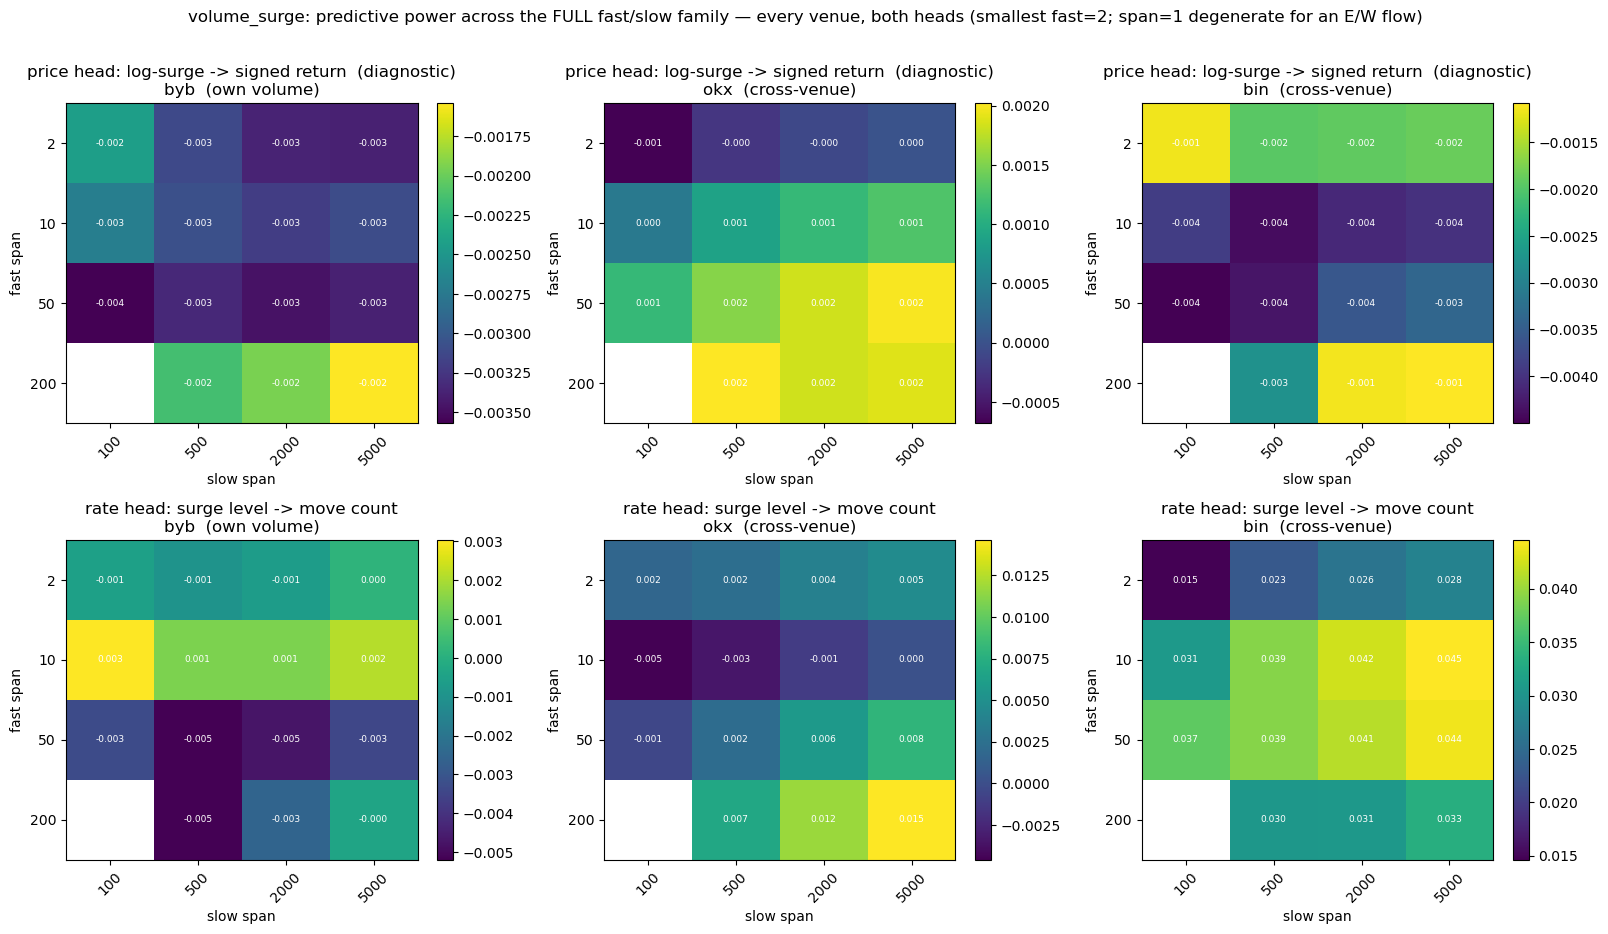

best family member per venue (in-sample pick; re-scored OOS below):
  byb:  price head (fast=50, slow=100) IC=-0.004   |  rate head (fast=50, slow=500) IC=-0.005
  okx:  price head (fast=200, slow=500) IC=0.002   |  rate head (fast=200, slow=5000) IC=0.015
  bin:  price head (fast=50, slow=100) IC=-0.004   |  rate head (fast=10, slow=5000) IC=0.045
does a 2nd span add over the pick? — price head: conditional partial-IC (in-sample screen) + walk-forward joint-vs-solo OOS:


  byb: best alt (f=2,s=5000) IC|best -0.002;  OOS joint +0.001 vs solo +0.002 (Δ-0.001)  ->  one span suffices (no OOS gain)


  okx: best alt (f=50,s=100) IC|best +0.001;  OOS joint +0.002 vs solo +0.003 (Δ-0.001)  ->  one span suffices (no OOS gain)


  bin: best alt (f=200,s=500) IC|best -0.002;  OOS joint +0.003 vs solo +0.003 (Δ-0.000)  ->  one span suffices (no OOS gain)
does a 2nd span add over the pick? — rate head: conditional partial-IC (in-sample screen) + walk-forward joint-vs-solo OOS:


  byb: best alt (f=10,s=5000) IC|best +0.008;  OOS joint +0.001 vs solo -0.004 (Δ+0.005)  ->  one span suffices (no OOS gain)


  okx: best alt (f=200,s=2000) IC|best -0.010;  OOS joint +0.014 vs solo +0.011 (Δ+0.002)  ->  one span suffices (no OOS gain)


  bin: best alt (f=200,s=5000) IC|best +0.020;  OOS joint +0.035 vs solo +0.041 (Δ-0.006)  ->  one span suffices (no OOS gain)


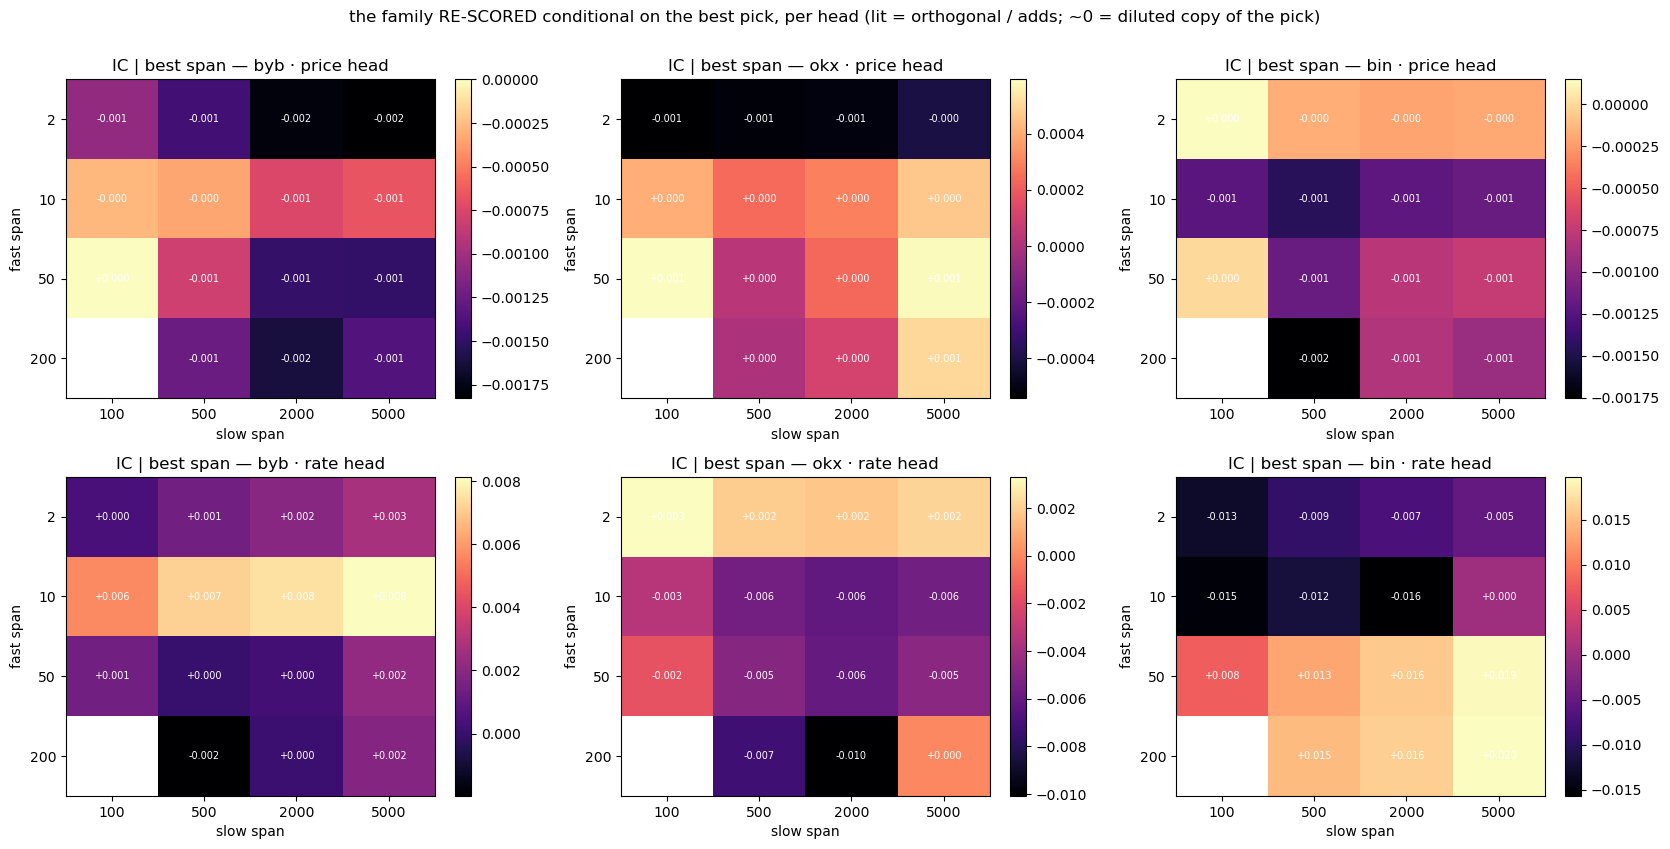

In [5]:
# Sweep the WHOLE family for EVERY venue, BOTH heads. Rate head uses the surge LEVEL (ratio) directly; price head uses log-surge.
price_grid = {ex: np.full((len(FAST), len(SLOW)), np.nan) for ex in EXCHANGES}   # log-surge -> byb's signed return
rate_grid  = {ex: np.full((len(FAST), len(SLOW)), np.nan) for ex in EXCHANGES}   # surge level -> byb's move count (rate_target)
feat_cache = {}
for ex in EXCHANGES:
    for i, nf in enumerate(FAST):
        for j, ns in enumerate(SLOW):
            if nf >= ns: continue
            s = volume_surge(ex, nf, ns); feat_cache[(ex, nf, ns)] = s
            ls = np.log(np.maximum(s, 1e-12))                              # log surge: symmetric around 0, the natural signed form
            price_grid[ex][i, j] = spearmanr(ls, target).statistic        # price head (diagnostic — expected weak)
            rate_grid[ex][i, j]  = spearmanr(s, rate_target).statistic     # rate head — surge level -> move count

fig, axes = plt.subplots(2, len(EXCHANGES), figsize=(5.4 * len(EXCHANGES), 9.2), squeeze=False)
for row, (grids, head) in enumerate([(price_grid, "price head: log-surge -> signed return  (diagnostic)"),
                                     (rate_grid,  "rate head: surge level -> move count")]):
    for col, ex in enumerate(EXCHANGES):
        ax = axes[row][col]; grid = grids[ex]; im = ax.imshow(grid, cmap="viridis", aspect="auto")
        ax.set_xticks(range(len(SLOW))); ax.set_xticklabels(SLOW, rotation=45); ax.set_xlabel("slow span")
        ax.set_yticks(range(len(FAST))); ax.set_yticklabels(FAST); ax.set_ylabel("fast span")
        ax.set_title(f"{head}\n{ex}" + ("  (own volume)" if ex == "byb" else "  (cross-venue)"))
        for i in range(len(FAST)):
            for j in range(len(SLOW)):
                if np.isfinite(grid[i, j]): ax.text(j, i, f"{grid[i, j]:.3f}", ha="center", va="center", color="w", fontsize=6.5)
        fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("volume_surge: predictive power across the FULL fast/slow family — every venue, both heads (smallest fast=2; span=1 degenerate for an E/W flow)", y=1.01)
fig.tight_layout(); plt.show()

# In-sample pick of the best family member PER head PER venue (used only to choose a time-scale; re-scored OOS by the gates).
def best_member(grid): return np.unravel_index(np.nanargmax(np.abs(grid)), grid.shape)
price_member = {ex: best_member(price_grid[ex]) for ex in EXCHANGES}
rate_member  = {ex: best_member(rate_grid[ex])  for ex in EXCHANGES}
print("best family member per venue (in-sample pick; re-scored OOS below):")
for ex in EXCHANGES:
    pi, pj = price_member[ex]; ri, rj = rate_member[ex]
    print(f"  {ex}:  price head (fast={FAST[pi]}, slow={SLOW[pj]}) IC={price_grid[ex][pi,pj]:.3f}"
          f"   |  rate head (fast={FAST[ri]}, slow={SLOW[rj]}) IC={rate_grid[ex][ri,rj]:.3f}")

# === Does a SECOND time-scale ADD over the pick? — the family RE-SCORED conditional on the best member, PER HEAD ===
# Selection lives here in §6. We picked the best (fast, slow) span per head by IC; now re-score the WHOLE family as
# partial-IC(cell | chosen) -- each cell's IC against the head's target, CONTROLLING for the span we picked (the
# same partial-IC tool the echo-netting cell uses; control = the chosen span, not the trailing move).
# A cell still LIT adds signal ORTHOGONAL to the pick; a cell that COLLAPSES to ~0 is a diluted copy. The heat-map
# is in-sample, so the keep/drop DECISION is the walk-forward joint-vs-solo OOS IC (wf_ic, imported in §5).
def _pic(f, y, c):                                                   # partial rank-IC of f with y, controlling for c
    m = np.isfinite(f) & np.isfinite(y) & np.isfinite(c)
    if m.sum() <= 100: return np.nan
    rfy = spearmanr(f[m], y[m]).statistic; rfc = spearmanr(f[m], c[m]).statistic; rcy = spearmanr(c[m], y[m]).statistic
    return (rfy - rfc * rcy) / np.sqrt(max((1.0 - rfc**2) * (1.0 - rcy**2), 1e-12))

# Per head: feat() maps a cell to its scored feature (price head = signed log-surge; rate head = surge LEVEL),
# tgt is the head's target, member is the in-sample pick.
HEADS = [("price head", lambda ex, nf, ns: np.log(np.maximum(volume_surge(ex, nf, ns), 1e-12)), target,      price_member),
         ("rate head",  lambda ex, nf, ns: volume_surge(ex, nf, ns),                            rate_target, rate_member)]
fig, axes = plt.subplots(len(HEADS), len(EXCHANGES), figsize=(5.6 * len(EXCHANGES), 4.2 * len(HEADS)), squeeze=False)
second = {}
for row, (head, feat, tgt, member) in enumerate(HEADS):
    print(f"does a 2nd span add over the pick? — {head}: conditional partial-IC (in-sample screen) + walk-forward joint-vs-solo OOS:")
    for col, ex in enumerate(EXCHANGES):
        ci, cj = member[ex]; chosen = feat(ex, FAST[ci], SLOW[cj])
        cond = np.full((len(FAST), len(SLOW)), np.nan)
        for i, nf in enumerate(FAST):
            for j, ns in enumerate(SLOW):
                if nf < ns: cond[i, j] = 0.0 if (i, j) == (ci, cj) else _pic(feat(ex, nf, ns), tgt, chosen)
        ax = axes[row][col]; im = ax.imshow(cond, cmap="magma", aspect="auto")
        ax.set_xticks(range(len(SLOW))); ax.set_xticklabels(SLOW); ax.set_xlabel("slow span")
        ax.set_yticks(range(len(FAST))); ax.set_yticklabels(FAST); ax.set_ylabel("fast span")
        ax.set_title(f"IC | best span — {ex} · {head}")
        for i in range(len(FAST)):
            for j in range(len(SLOW)):
                if np.isfinite(cond[i, j]): ax.text(j, i, f"{cond[i, j]:+.3f}", ha="center", va="center", color="w", fontsize=7)
        fig.colorbar(im, ax=ax, fraction=0.046)
        bi, bj = np.unravel_index(np.nanargmax(np.abs(cond)), cond.shape)          # the most-orthogonal alternative cell (in-sample screen)
        f1, f2 = chosen, feat(ex, FAST[bi], SLOW[bj])
        solo, joint = wf_ic([f1], tgt), wf_ic([f1, f2], tgt)                       # OOS: chosen alone vs the pair
        keep = bool((joint - solo) >= 0.01)                                        # the OOS joint gain DECIDES
        second[(head, ex)] = (bi, bj) if keep else None
        print(f"  {ex}: best alt (f={FAST[bi]},s={SLOW[bj]}) IC|best {cond[bi, bj]:+.3f};  OOS joint {joint:+.3f} vs solo {solo:+.3f} (Δ{joint - solo:+.3f})"
              f"  ->  {'KEEP 2nd span (adds OOS)' if keep else 'one span suffices (no OOS gain)'}")
fig.suptitle("the family RE-SCORED conditional on the best pick, per head (lit = orthogonal / adds; ~0 = diluted copy of the pick)", y=1.005)
fig.tight_layout(); plt.show()

**Does a *second* time-scale add — per head?** The IC heat-map picks the best (fast, slow) span per head; a second
span is only worth feeding if it carries signal the first doesn't. We test that by **re-scoring the whole family
conditional on the chosen pick** — each cell's IC recomputed as `partial-IC(cell | chosen)`: its predictive power
against the head's target **controlling for the span we already picked** (the same partial-IC tool the
echo-netting cell uses; control = the chosen span). A cell that stays **lit** is **orthogonal** — it adds new
signal — while a cell that **collapses to ≈ 0** is a diluted copy of the pick. Because that heat-map is
**in-sample**, the keep/drop **decision** is the overfitting-resistant **walk-forward joint-vs-solo** IC
(`wf_ic([chosen, alt]) − wf_ic([chosen])`): keep the second span only when the out-of-sample gain clears the
~0.01 floor. We run it for **both heads** (price → signed log-surge vs the σ-return target; rate → surge level vs
the count target), **per venue**. Read the printed per-exchange verdict for this block — where the second span is
a diluted copy (OOS gain ≈ 0) one span per head suffices.

**Now the gates** — and they are **two independent tests**, not one. Every *predictive* number is the
**walk-forward** mean (causal, purged).

One caveat for **both heads**: the fast/slow span is chosen by the in-sample heat-map *above* over the
**whole** block, so the walk-forward IC below is **post-selection and provisional** — mildly optimistic,
since the test folds also informed the span pick. Held-out span selection is deferred to the multi-block
`tools/oss` harness; here the choice is among a small 4×4 fast/slow grid of near-identical neighbours, so
the selection bias is expected to be small (we don't measure it on this single block).

**Gate A — regime invariance** (the feature *alone*): is the feature's distribution **stable against our regime
diagnostics**, or does it *leak* it? **Control-free** checks: **scale** — its std across vol buckets (max/min,
want **< ~3**); and then, for **both the signed feature *and* its magnitude `|feature|`** (the rate head
receives the *signed* feature and can learn its magnitude), two leak modes against **both regime coordinates**
(vol *and* rate level): **tracking** — `|IC(·, level)|` ≈ 0 (the monotone test, want **< ~0.05** for the
signed feature, **< ~0.1** for the magnitude), and **dispersion** — the spread of its per-decile *means*
(want **< ~0.1**), which catches a *non-monotone* leak the monotone IC misses. The vol/rate level is only the
regime *coordinate* here (what we bucket/correlate against), **never** a control. Fail any one of them = a
level in disguise, not a feature. *(For a dimensionless surge **ratio** we expect scale to be steady and
tracking small — but `volume_surge` is a volume regime descriptor, and a venue's traded volume correlates
with byb's vol/rate regime, so this is exactly where a leak could appear; we measure, never assume.)*

**Gate B — predictive signal**: does it predict? `volume_surge` is a **control** (a volume regime
descriptor), but — the crux — the controls are the **move** rate while the feature is the **traded volume**,
and volume ≠ move rate, so there is **no circular own-leg** here. Every leg (byb, okx, bin) is judged on its
**marginal** rank-IC over the regime-invariant controls (the momenta — **never** the raw levels),
`own=False` — the honest "does volume add over move tempo?" test, jointly and per leg. **Mechanical-coupling
guard:** the surge is `(E/W)_fast(qty) / (E/W)_slow(qty)`, a self-ratio of the same quantity, so the qty
units and any common decay/warm-up factor **cancel** — it divides by **no** yardstick of either target — so
there is no spurious ratio coupling to stratify away (`STRAT_VAR = None`). *Regime-stable* (companion): is the
gain still positive **within** calm, mid, and wild vol — not a one-regime artefact?

In [6]:
# Gates on the set of per-venue features — symmetric; KEEP ALL venues. We run the RATE head (the feature's home).
# GATE B — predictive signal.  volume_surge is a CONTROL (a volume regime descriptor), BUT the control is the MOVE rate
# while the feature is the traded VOLUME (volume != move rate), so there is NO circular own-leg: EVERY leg
# (byb included) is judged on its MARGINAL rank-IC over the base momenta -> own=False (the honest "volume over move tempo" test).
# signal_ic / signal_ic_by_regime / stratified_ic / ic all come from boba.research.gates (the §5 wrappers bind
# base / FEATURE_KIND / STRAT_VAR / vol_regime). STRAT_VAR=None (the surge divides by no yardstick), so the marginal
# branch is the usual nested-model incremental IC for every leg.
surge = {ex: feat_cache[(ex, FAST[rate_member[ex][0]], SLOW[rate_member[ex][1]])] for ex in EXCHANGES}  # rate-head pick per venue

# rate head, scored against the COUNT target. EVERY leg (byb included) -> marginal-over-controls (own=False).
each_marg   = {ex: signal_ic([surge[ex]], own=False, tgt=rate_target) for ex in EXCHANGES}              # per-leg marginal over the MOVE-rate controls
joint_marg  = signal_ic(list(surge.values()), own=False, tgt=rate_target)                               # all three legs jointly
cross_joint = signal_ic([surge["okx"], surge["bin"]], own=False, tgt=rate_target)                       # okx+bin cross-venue legs only
jci = wf_marginal_ci(list(surge.values()), rate_target)   # per-fold spread + block-bootstrap CI for the joint marginal
strat = signal_ic_by_regime(list(surge.values()), own=False, tgt=rate_target)  # the calm/mid/wild companion (all legs)
print(f"byb OWN-volume marginal (over the MOVE-rate controls) {each_marg['byb']:.3f}  <- the volume-vs-move-rate test")
print(f"all three legs JOINT marginal {joint_marg:.3f}  |  per-fold {jci['per_fold']} (positive in {jci['pos']}/{jci['nf']})  "
      f"|  block-bootstrap 90% CI [{jci['ci'][0]}, {jci['ci'][1]}]  (block ~{jci['block_len']} anchors ~{jci['block_s']}s)")
print(f"okx+bin CROSS-VENUE joint marginal {cross_joint:.3f}")

# LOW-1 sanity: a "control" SHOULD overlap the momenta (it IS a regime descriptor) — but the traded VOLUME need not
# overlap the MOVE-rate momenta strongly, since volume != move rate.
rep = surge["byb"]
print(f"FEATURE_KIND={FEATURE_KIND!r} | byb volume-surge vs momenta |IC|: rate {abs(ic(rep, rate_momentum)):.3f} vol {abs(ic(rep, vol_momentum)):.3f}  (vs MOVE-rate momentum: how much traded volume tracks the move tempo)")

gate_rows = [dict(gate="B · signal (rate)", detail=f"{ex} leg alone — marginal surge->count over the MOVE-rate controls"
                  + ("  [byb own volume vs MOVE-rate control]" if ex == "byb" else "  [cross-venue volume tempo]"),
                  value=each_marg[ex]) for ex in EXCHANGES]
gate_rows += [dict(gate="B · signal (rate)", detail="all three venues JOINTLY — marginal over the controls", value=joint_marg),
              dict(gate="B · signal (rate)", detail="okx+bin cross-venue legs JOINTLY — marginal over the controls", value=cross_joint)]
for ex in EXCHANGES:                                       # GATE A PER VENUE (worst coordinate per check) — the output distribution differs by venue
    a = gate_a(surge[ex])
    gate_rows += [dict(gate=f"A · regime-inv ({ex})", detail="feature scale across vol buckets (max/min) — HARD, want < ~3", value=a["scale"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="|IC(feature, vol/rate level)| — signed mean-track, worst coord; want < ~0.05", value=a["track"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="|IC(|feature|, vol/rate level)| — magnitude track (the signed-fed rate head can learn it), worst coord; want < ~0.1", value=a["mag"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="non-monotone leak — per-decile-mean dispersion (mean & magnitude), worst; want < ~0.1", value=a["disp"])]
gate_rows += [dict(gate="regime-stable (rate)", detail=f"joint marginal within {nm}-vol (companion: stay positive)", value=strat.get(r, float("nan")))
              for r, nm in [(0, "calm"), (1, "mid"), (2, "wild")]]
pl.Config.set_tbl_rows(30); pl.Config.set_fmt_str_lengths(70)
pl.DataFrame(gate_rows)

byb OWN-volume marginal (over the MOVE-rate controls) -0.000  <- the volume-vs-move-rate test
all three legs JOINT marginal 0.010  |  per-fold [0.005, 0.014, 0.015, 0.014, 0.002] (positive in 5/5)  |  block-bootstrap 90% CI [0.008, 0.012]  (block ~9479 anchors ~474.0s)
okx+bin CROSS-VENUE joint marginal 0.010


FEATURE_KIND='control' | byb volume-surge vs momenta |IC|: rate 0.046 vol 0.052  (vs MOVE-rate momentum: how much traded volume tracks the move tempo)


gate,detail,value
str,str,f64
"""B · signal (rate)""","""byb leg alone — marginal surge->count over the MOVE-rate controls [by…",-0.0
"""B · signal (rate)""","""okx leg alone — marginal surge->count over the MOVE-rate controls [cr…",0.0
"""B · signal (rate)""","""bin leg alone — marginal surge->count over the MOVE-rate controls [cr…",0.011
"""B · signal (rate)""","""all three venues JOINTLY — marginal over the controls""",0.01
"""B · signal (rate)""","""okx+bin cross-venue legs JOINTLY — marginal over the controls""",0.01
"""A · regime-inv (byb)""","""feature scale across vol buckets (max/min) — HARD, want < ~3""",1.2
"""A · regime-inv (byb)""","""|IC(feature, vol/rate level)| — signed mean-track, worst coord; want <…",0.053
"""A · regime-inv (byb)""","""|IC(|feature|, vol/rate level)| — magnitude track (the signed-fed rate…",0.053
"""A · regime-inv (byb)""","""non-monotone leak — per-decile-mean dispersion (mean & magnitude), wor…",0.043


**Conclusion — read per leg, against the volume-vs-move-rate distinction.** `volume_surge` is a **control**
(a volume regime descriptor), and the headline numbers are the **marginal values over the move-rate/vol
momenta** on the **rate head**, reported straight. The crux: the control is the *move* rate while the
feature is the *traded volume*, and volume ≠ move rate, so even the **byb** leg is judged on its
**marginal** (not forced to a circular standalone read). Read the printed table for this run:
- The **byb own-volume marginal** over the move-rate controls is the volume-vs-move-rate test — does byb's
  traded volume add over what its move-rate regime already says?
- The **okx** and **bin** cross-venue legs add (or not) on top; the **joint** marginal (all three) and the
  **okx+bin cross-venue** marginal say whether another venue's volume tempo genuinely leads byb's move-count.
- **Gate A** is run per venue (a distribution property): scale should be ≪ 3 and the signed feature should
  barely track the regime; because `volume_surge` is itself a volume regime descriptor, a venue whose volume
  correlates with byb's `rate_level`/`λ_ev` is the feature being honest about what it is (allowed for a
  control), not a disqualifying "level in disguise" — provided dispersion stays small (no non-monotone leak).
- The **companion** says whether the joint marginal is a one-regime artefact or holds across calm/mid/wild.

Quote the **§6 marginal**, never a raw IC. (Read the exact per-leg numbers, the joint CI and per-fold count,
and the Gate A / companion rows in the printed table — they are this block's verdict.)

## Is the edge real prediction, or an echo of the move already underway?

A feature can be perfectly causal and still not *predict*: if its apparent edge is the price move **already
underway** at the anchor, you can't capture it — by the time you observe, decide, and act, that move is gone — and
a purely *contemporaneous* feature can post a positive forward IC from window overlap alone. So before trusting a
forward IC, **net out the echo**: measure the feature's correlation with the **forward** return
(`[anchor, anchor+100 ms]`) *controlling for the move that already happened* (`[anchor-100 ms, anchor]`). The
**backward IC** sizes the echo; the **echo-netted** forward IC is what survives once it's partialled out — the
genuinely forward-looking edge. (It's the same partial-IC tool §6 uses to test a second time-scale — here the
control is the trailing move instead of the chosen span.)

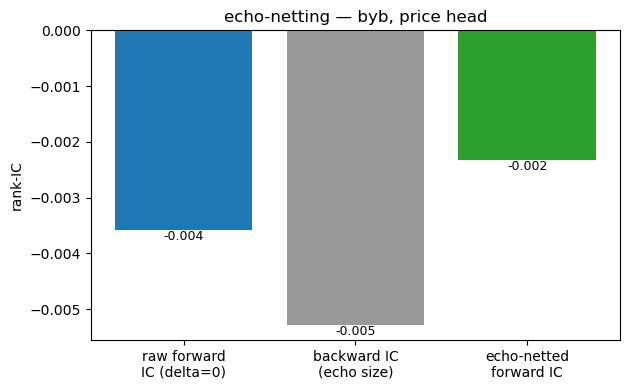

raw forward IC -0.004;  backward (echo) IC -0.005;  echo-netted forward IC -0.002  (the raw->netted shortfall is echo)


In [7]:
# Echo-netting: is the edge real prediction, or just re-reporting the move ALREADY underway at the anchor?
rep_ex = EXCHANGES[0]                                    # one exchange to illustrate; every leg carries its own
def _ic(feat, ret):
    v = np.isfinite(feat) & np.isfinite(ret)
    return spearmanr(feat[v], ret[v]).statistic if v.sum() > 100 else float("nan")
def _mid_at(t):                                          # byb mid at-or-before t (causal)
    idx = np.searchsorted(byb_rx, t, "right") - 1; return np.where(idx < 0, np.nan, byb_mid[np.clip(idx, 0, len(byb_mid) - 1)])   # nan before byb's first quote
def _ret(t0, t1): return np.log(_mid_at(t1) / _mid_at(t0))
def _partial_ic(f, y, t):                                # partial rank-IC of f with y, CONTROLLING for t
    v = np.isfinite(f) & np.isfinite(y) & np.isfinite(t)
    if v.sum() <= 100: return float("nan")
    rfy = spearmanr(f[v], y[v]).statistic; rft = spearmanr(f[v], t[v]).statistic; rty = spearmanr(t[v], y[v]).statistic
    return (rfy - rft*rty) / np.sqrt(max((1.0 - rft**2) * (1.0 - rty**2), 1e-12))

signed = np.log(np.maximum(volume_surge(rep_ex, FAST[price_member[rep_ex][0]], SLOW[price_member[rep_ex][1]]), 1e-12))   # the chosen price-head feature (signed log-surge)
_fwd0  = _ret(anchor_ts, anchor_ts + HORIZON_NS)          # forward 100 ms return — what we predict
_trail = _ret(anchor_ts - HORIZON_NS, anchor_ts)          # the move ALREADY underway at the anchor
raw_ic   = _ic(signed, _fwd0)                             # raw forward IC
back_ic  = _ic(signed, _trail)                            # backward IC — sizes the contemporaneous echo
echo_net = _partial_ic(signed, _fwd0, _trail)             # forward IC NETTED of the echo (controls for the trailing move)

fig, ax = plt.subplots(figsize=(6.4, 4.0))
labels = ["raw forward\nIC (delta=0)", "backward IC\n(echo size)", "echo-netted\nforward IC"]
vals = [raw_ic, back_ic, echo_net]
bars = ax.bar(labels, vals, color=["C0", "0.6", "C2"])
ax.axhline(0, color="0.7", lw=0.8); ax.set_ylabel("rank-IC"); ax.set_title(f"echo-netting — {rep_ex}, price head")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:+.3f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=9)
fig.tight_layout(); plt.show()
print(f"raw forward IC {raw_ic:+.3f};  backward (echo) IC {back_ic:+.3f};  echo-netted forward IC {echo_net:+.3f}  (the raw->netted shortfall is echo)")

**Net the echo out — don't report a forward IC a contemporaneous predictor could fake.** The cleanest
"is this real prediction?" number is the **echo-netted (partial) forward IC** above: the feature's rank-IC with
the *forward* return *controlling for the trailing* `[anchor-100 ms, anchor]` return. If a big raw IC collapses
once the trailing move is partialled out, the feature was mostly re-reporting the move already underway — report
the **netted** number in the verdict, not the raw IC. (A near-zero netted IC alongside a large backward IC is the
one true non-signal: all echo, no prediction.)

**Cross-venue legs: a freshness lead is *real edge*, not an artifact to coarsen away.** The data is recorded
on a production box in the target datacenter, so each event's `rx_time` is exactly the timing you'd see live —
there is **no recording/snapshot artifact** to rule out. So when okx's book moves before byb's reflects it
(byb/okx top-of-book is stale p90 ~100-160 ms vs bin's sub-ms), that lead is **genuine and exploitable**, and
the *mechanism* (economic price-discovery vs pure latency lead-lag) is irrelevant to P&L. Do **not** coarsen the
foreign feed to byb's cadence — that throws the edge away. *(A freshness lead would only be fake if the
recording's cadence didn't match production — e.g. a backtest on vendor snapshots; not the case here, where the
recording* is *production timing.)*

## 7. What the prediction actually looks like

A single correlation hides *how* the feature changes the outcome. Group the data by the feature and look
at the real distributions the heads care about, **per venue** (byb's own volume vs the cross-venue legs):
- **rate head (its home):** how the number of upcoming byb moves grows as each venue's volume-surge ratio grows;
- **price head (diagnostic):** byb's next return for low / middle / high *signed* (log-)surge — expected
  roughly flat, since intensity isn't direction.

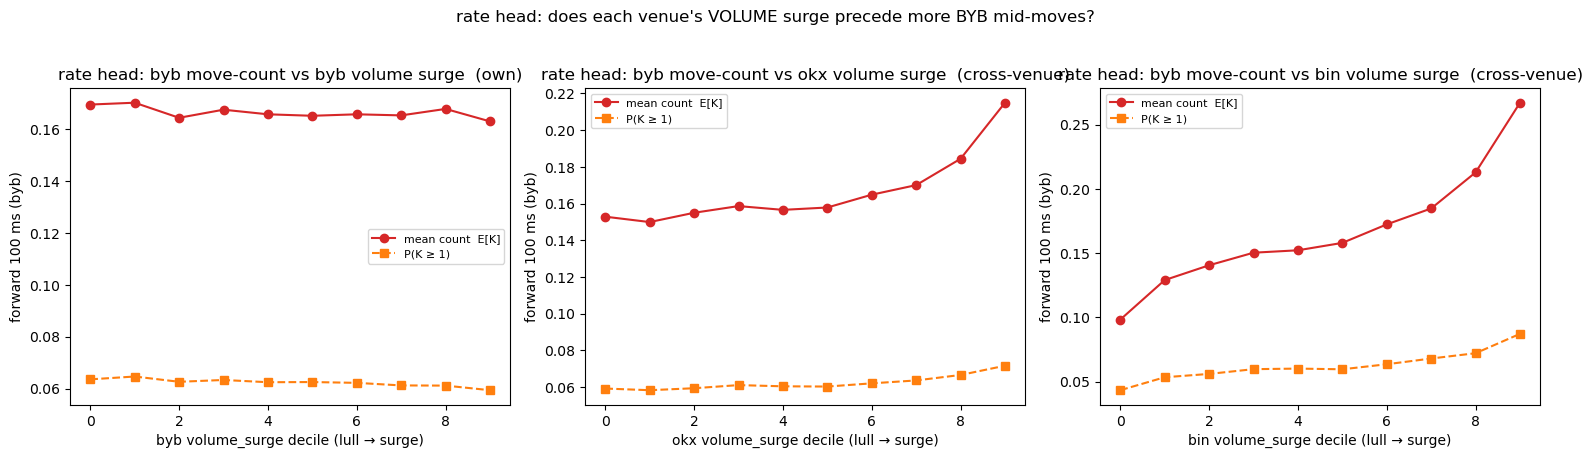

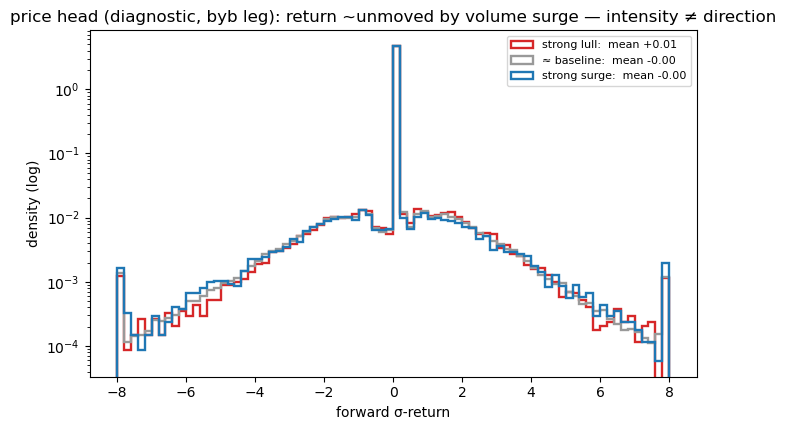

In [8]:
fig, axes = plt.subplots(1, len(EXCHANGES), figsize=(5.2 * len(EXCHANGES), 4.4), squeeze=False)
for col, ex in enumerate(EXCHANGES):
    s = surge[ex]; ax = axes[0][col]
    dec = np.digitize(s, np.nanpercentile(s[np.isfinite(s)], np.arange(10, 100, 10)))
    ax.plot(range(10), [fwd_count[dec == b].mean() for b in range(10)], "o-", color="C3", label="mean count  E[K]")
    ax.plot(range(10), [(fwd_count[dec == b] >= 1).mean() for b in range(10)], "s--", color="C1", label="P(K ≥ 1)")
    ax.set_xlabel(f"{ex} volume_surge decile (lull → surge)"); ax.set_ylabel("forward 100 ms (byb)")
    ax.set_title(f"rate head: byb move-count vs {ex} volume surge" + ("  (own)" if ex == "byb" else "  (cross-venue)")); ax.legend(fontsize=8)
fig.suptitle("rate head: does each venue's VOLUME surge precede more BYB mid-moves?", y=1.03)
fig.tight_layout(); plt.show()

# price head (diagnostic): forward σ-return across signed log-surge buckets — expected ~flat — shown for the byb leg
s = surge["byb"]; ls = np.log(np.maximum(s, 1e-12))
fig, axB = plt.subplots(1, 1, figsize=(7, 4.4))
lo, hi = np.nanpercentile(ls, [10, 90])
groups = [("strong lull", ls <= lo, "C3"), ("≈ baseline", (ls > lo) & (ls < hi), "0.6"), ("strong surge", ls >= hi, "C0")]
bins = np.linspace(-8, 8, 81)
for lab, m, col in groups:
    axB.hist(np.clip(target[m & np.isfinite(target)], -8, 8), bins=bins, density=True,
             histtype="step", color=col, lw=1.7, label=f"{lab}:  mean {np.nanmean(target[m]):+.2f}")
axB.set_yscale("log"); axB.set_xlabel("forward σ-return"); axB.set_ylabel("density (log)")
axB.set_title("price head (diagnostic, byb leg): return ~unmoved by volume surge — intensity ≠ direction"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** **Rate head (top row):** read the per-venue panels for this block — for the **byb** leg the
mean move-count `E[K]` and `P(K ≥ 1)` track the venue's volume-surge deciles (the §1 intensity story: a
volume surge precedes more byb moves), and the **okx/bin** panels show whether *another* venue's volume
surge also tracks byb's upcoming move-count (a cross-venue lead, quantified by the §6 marginals). **Price
head (bottom):** the forward-return distribution barely shifts across lull / baseline / surge groups (group
means ≈ 0 — read the legend) — a surge says *how many*, not *which way*, confirming this is an intensity
feature. So the feature moves the actual outcome distributions the rate head needs, and the open question
§6 answers is whether any leg's signal is **new** over `rate_momentum` — and here, because the control is the
*move* rate and this is the *traded volume*, even byb's own leg has a genuine shot.

## 8. Input shaping for the network

This reshapes the feature for the network's input — roughly centred, unit-scale, no wild outliers — a
*different* step from §2 (there is no regime division here; the feature is already a ratio). A surge
*ratio* is positive and right-skewed (a surge can be several× baseline; a lull is floored at 0), so its
**log** is the natural signed, centred form. We feed **every venue's** log-surge (none privileged). Plot the
byb leg (left) and compare candidates by how close to a clean bell curve they make it (right — points on the
diagonal are perfectly normal). Pick the lightest transform that clears the bar; the same transform applies
per venue.

raw ratio: skew=+3.54  excess_kurt=22.6
log surge: skew=-0.10  excess_kurt=0.2  (0 = normal)
  raw ratio (z)          excess_kurt=  22.6   max|·|=25.0
  log surge (z)          excess_kurt=   0.2   max|·|=5.4
  log robust + clip ±4   excess_kurt=   0.2   max|·|=4.0
  rank-Gaussian(log)     excess_kurt=  -0.0   max|·|=5.0


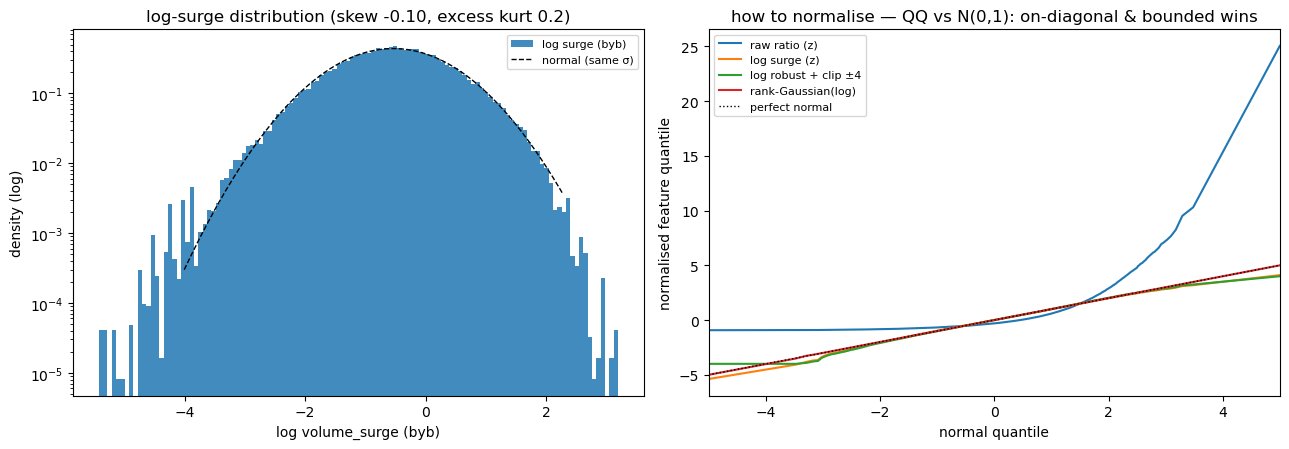

In [9]:
from scipy.stats import skew, kurtosis, rankdata, norm
f = surge["byb"]; f = f[np.isfinite(f) & (f > 0)]
lf = np.log(f)                                       # log surge: the natural centred, signed form of a ratio
med = np.median(lf); mad = 1.4826 * np.median(np.abs(lf - med)) + 1e-12; rz = (lf - med) / mad
cand = {"raw ratio (z)": (f - f.mean()) / f.std(),
        "log surge (z)": (lf - lf.mean()) / lf.std(),
        "log robust + clip ±4": np.clip(rz, -4, 4),
        "rank-Gaussian(log)": norm.ppf((rankdata(lf) - 0.5) / len(lf))}
print(f"raw ratio: skew={skew(f):+.2f}  excess_kurt={kurtosis(f):.1f}")
print(f"log surge: skew={skew(lf):+.2f}  excess_kurt={kurtosis(lf):.1f}  (0 = normal)")
for name, v in cand.items():
    print(f"  {name:22} excess_kurt={kurtosis(v):>6.1f}   max|·|={np.abs(v).max():.1f}")

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))
axA.hist(lf, bins=120, density=True, color="C0", alpha=.85, label="log surge (byb)")
xg = np.linspace(np.percentile(lf, 0.05), np.percentile(lf, 99.95), 300)
axA.plot(xg, norm.pdf(xg, lf.mean(), lf.std()), "k--", lw=1, label="normal (same σ)")
axA.set_yscale("log"); axA.set_xlabel("log volume_surge (byb)"); axA.set_ylabel("density (log)")
axA.set_title(f"log-surge distribution (skew {skew(lf):+.2f}, excess kurt {kurtosis(lf):.1f})"); axA.legend(fontsize=8)

q = norm.ppf((np.arange(1, len(lf) + 1) - 0.5) / len(lf)); sub = np.linspace(0, len(lf) - 1, 4000).astype(int)
for name, v in cand.items():
    axB.plot(q[sub], np.sort(v)[sub], lw=1.5, label=name)
axB.plot([-5, 5], [-5, 5], "k:", lw=1, label="perfect normal")
axB.set_xlim(-5, 5); axB.set_xlabel("normal quantile"); axB.set_ylabel("normalised feature quantile")
axB.set_title("how to normalise — QQ vs N(0,1): on-diagonal & bounded wins"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** Read the printout for this run. The **raw surge ratio** is right-skewed and fat-tailed (a
surge can be several× baseline, a lull is floored at 0), so a plain z-score leaves skew and a long right
tail. Taking the **log** first symmetrises it (skew toward 0) — the natural transform for a positive ratio,
since `log(volume_surge) = log(E/W)_fast − log(E/W)_slow` is a difference of log-means. Note the raw ratio
is **not centred at 1**: it is right-skewed with a median ≈ 0.3 here, so the log lands centred ≈ −1.2 — the
**robust-z** step then re-centres on that median (subtract median, scale by MAD), which is exactly why the
transform does not need the raw ratio to sit at 1. The lightest transform that *also* tames the tails to
clear the "no wild outliers" bar is **log → robust-z →
clip ±4** (bounded at max|·| = 4); the heavier rank-Gaussian flattens further but throws away the magnitude
ordering the rate head wants. So feed `log(volume_surge)` per venue, robust-z-scored and clipped — every
venue, none privileged. (Read the exact skew / excess-kurtosis / max|·| numbers in the printout — they are
this block's evidence for the choice.)

## 9. When is per-exchange worth it?

`volume_surge` is computed independently for every venue (byb's own volume, okx's own, bin's own), so —
unlike the template's cross-venue *gap* (a quantity *between* two exchanges, with no single "pooled"
version) — the per-exchange / single / **pooled** choice is genuinely available here: you *could* average
the three venues' surge into one activity gauge. So the template's §9 question really applies, and the
answer is **time-scale-dependent**: per-exchange is the safe default, and the value of the extra venues
shrinks as the time-scale grows and the venues' volume regimes converge.

> **This is an illustrative note, not a computed table — matching the old `volume_surge` analysis.** The
> §6 heat-maps already show each venue's per-time-scale IC, and the original `volume_surge` notebook left
> the full pooled-vs-single-vs-per-exchange sweep as the natural follow-up rather than computing it here (a
> per-venue surge *can* be pooled — unlike the template's gap — so the sweep is well-defined; it just wasn't
> run in this single-block analysis). The typical pattern, predicting byb's next 100 ms:

| time-scale (lookback) | pooled | best single | per-exchange | what it means |
|---|---|---|---|---|
| short slow span | ≈ per-ex | ≈ per-ex | **best** | venues differ — who is accelerating in size first; keep them separate |
| medium slow span | blurs | good | **best** | the middle band where per-exchange genuinely pays off |
| long slow span | ≈ single | ≈ single | ≈ single | the volume regimes converge — one venue says what the rest do |

For the **target's own move-rate**, byb's *own* `volume_surge` is the most directly relevant venue (its
trades drive its book), but okx/bin volume can lead during cross-venue bursts — which is exactly why we keep
**all three** per-exchange and let the model weight whichever is leading. A full computed sweep (the real
per-exchange-vs-single-vs-pooled walk-forward, as the sibling `trade_rate_surge_v2` runs) is the natural
next step before shipping.

## 10. The verdict, and what it takes to ship

**Keep the per-venue family — feed every venue's *signed* log-surge to the rate head — but label each leg
for what it is:**
- **Rate head (intensity):** `volume_surge` is the natural input — a fast mean-qty over a slow one; the
  surge ratio predicts byb's move-count (§6/§7). Sweep the (fast, slow) family **per venue** and let the
  data pick (§6 heat-maps), then ask **whether a *second* time-scale adds over the pick** — the §6
  conditional-IC re-scoring (`partial-IC(cell | chosen)`) with the keep/drop decided by the walk-forward
  joint-vs-solo OOS gain (~0.01 floor). Feed the second span per head/venue only where that OOS gain clears
  the floor; otherwise one span suffices. Keep all three venues per-exchange (§9 illustrative note: the
  venues differ at short lookbacks and converge at long ones; the full pooled-vs-single-vs-per-exchange
  sweep is the natural follow-up).
- **Price head (direction):** ≈0 — don't feed it expecting direction; it's an intensity feature.
- **Feature form:** `log(volume_surge)` per venue, robust-z, clip ±4 (§8). **No yardstick division** —
  it's already a dimensionless ratio (and so `STRAT_VAR = None`: it shares no denominator with either target).

**The control verdict — traded VOLUME vs MOVE rate (the headline).** `volume_surge` is
`FEATURE_KIND="control"` — a volume regime descriptor — but the key point: the control is the **move** rate
(`rate_momentum`, from `λ_ev`) while the feature counts **traded volume**, and the two genuinely decouple (a
heavy print need not move the mid; the mid moves without a heavy print) — so there is **no circular
own-leg**, and even the **byb** leg is judged on its **marginal** over the move-rate controls, an honest
test of whether volume carries intensity the move-rate regime misses. **The headline number is the §6
joint/per-leg marginal over the move-rate/vol momenta on the rate head** — read it (and the per-fold count,
the block-bootstrap CI, the okx+bin cross-venue marginal, the Gate A rows and the calm/mid/wild companion)
straight off the §6 gate table for this block. Always quote the **§6 marginal** (echo-netted for the
echo-heavy legs), never a raw IC.

**The echo-netting verdict — real prediction vs the move already underway.** A raw δ=0 IC can be a
contemporaneous echo of the burst already underway at the anchor, not genuine forward prediction. The
echo-netting section nets it out: the feature's rank-IC with the **forward** return **controlling for the
trailing** `[anchor−100 ms, anchor]` move (a partial Spearman) — the **backward IC** sizes the echo, the
**echo-netted** forward IC is what survives. If a big raw IC collapses once the trailing move is partialled
out, the leg was mostly re-reporting the past, and the verdict must quote the **netted** number, not the raw
δ=0 IC. For the **cross-venue** okx/bin legs the freshness lead is **real, exploitable edge** — the data is
production datacenter timing, so there is no recording/snapshot artifact to coarsen away. **Read the
echo-netting chart and print for the realised call on this block**, and quote the **echo-netted** number in
any decision to keep or drop a leg.

**To ship:**
- [x] the streaming (constant-work-per-trade) builder, per venue, matching this analysis version **bit-exact** (§4)
- [x] the §4 parity check passing on a real block, with simultaneous prints summed into one event
- [ ] the §6 marginal-over-`rate_momentum` recorded **per leg** (byb included), with the volume-vs-move-rate call made
- [x] echo-netted (partial) forward IC recorded — the **netted** number cited (raw→netted shortfall = echo), not the raw δ=0 IC
- [x] the §6 second-time-scale conditional-IC recorded **per head** — `partial-IC(cell | chosen)` re-scoring with the walk-forward joint-vs-solo OOS keep/drop decision
- [ ] the §9 per-exchange-vs-single-vs-pooled sweep computed (left as an illustrative note here, matching the old analysis — the natural follow-up before shipping)
- [ ] the chosen rate-head time-scale per venue written down, with the yardstick span
- [x] the data quirks handled (bad zero-price/zero-qty prints filtered; qty summed per timestamp into one event)